In [3]:
import copy
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim

from scipy import stats
from sklearn.metrics import (
    auc,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import importlib
import modules

importlib.reload(modules)

from modules import *
from utils import *


DTYPE = torch.float32
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE:", DEVICE)


# ============================================================
# 固定随机种子
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 计算分类指标
# ============================================================
def compute_metrics(cm, targets, probs):
    tn = float(cm[0, 0])
    fp = float(cm[0, 1])
    fn = float(cm[1, 0])
    tp = float(cm[1, 1])

    eps = 1e-12

    sensitivity = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    ppv = tp / (tp + fp + eps)
    npv = tn / (tn + fn + eps)

    accuracy = (
        (tp + tn)
        / (tp + tn + fp + fn + eps)
    )

    f1 = (
        2 * ppv * sensitivity
        / (ppv + sensitivity + eps)
    )

    try:
        auc_value = roc_auc_score(
            targets,
            probs
        )
    except ValueError:
        auc_value = np.nan

    return {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Accuracy": accuracy,
        "F1": f1,
        "AUC": auc_value,
    }


# ============================================================
# 均值、标准差、标准误和95%置信区间
# ============================================================
def mean_ci(values, alpha=0.05):
    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        ~np.isnan(values)
    ]

    n = len(values)

    if n == 0:
        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    mean_value = float(
        values.mean()
    )

    if n < 2:
        return (
            mean_value,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    std_value = float(
        values.std(ddof=1)
    )

    sem_value = (
        std_value / np.sqrt(n)
    )

    t_critical = stats.t.ppf(
        1 - alpha / 2,
        df=n - 1
    )

    ci_lower = (
        mean_value
        - t_critical * sem_value
    )

    ci_upper = (
        mean_value
        + t_critical * sem_value
    )

    return (
        mean_value,
        std_value,
        sem_value,
        ci_lower,
        ci_upper,
    )


# ============================================================
# 主实验
#
# 当前函数用于：
# 1. 在训练集上训练
# 2. 在验证集上选择最佳epoch
# 3. 在验证集上选择内部冠军模型和随机种子
# 4. 测试集暂时封存，不参与本阶段评价
#
# 当前结果只能称为VAL结果，不能称为最终TEST结果
# ============================================================
def experiment(
    data_path,
    save_path,
    num_cluster,
    experiment_repeats=2,
    repeats=2,
    epochs=200,
    sparsity_lambda=1e-2,
    temp_start=1.0,
    temp_end=0.3,
    seed=42,
    panel_threshold=0.5,
):

    set_seed(seed)

    out_dir = os.path.dirname(
        save_path
    )

    os.makedirs(
        out_dir,
        exist_ok=True
    )

    # ========================================================
    # 读取数据
    # ========================================================
    data = sio.loadmat(
        data_path
    )

    samples = torch.tensor(
        data["X"],
        dtype=DTYPE
    )

    labels = torch.tensor(
        data["y"],
        dtype=DTYPE
    ).view(-1).long()

    voc_names = [
        str(value.flat[0])
        for value in data[
            "feat_names"
        ].flatten()
    ]

    print(
        f"样本数: {samples.shape[0]}"
    )

    print(
        f"特征数: {samples.shape[1]}"
    )

    print(
        f"类别数量: "
        f"{torch.bincount(labels).tolist()}"
    )

    # ========================================================
    # 外层数据划分
    #
    # 80%：训练池
    # 20%：封存测试集
    #
    # 注意：本函数中不使用sealed_test_loader
    # ========================================================
    train_pool_loader, sealed_test_loader, _ = split_dataset(
        samples,
        labels,
        batch_size=16,
        split_length=[0.8, 0.2]
    )

    # 读取训练池中的全部数据
    temporary_loader = DataLoader(
        train_pool_loader.dataset,
        batch_size=len(
            train_pool_loader.dataset
        ),
        shuffle=False
    )

    x_pool, y_pool = next(
        iter(temporary_loader)
    )

    # 保留测试集变量，但本阶段不使用
    print(
        "测试集已封存，本阶段不参与模型和随机种子筛选。"
    )

    # ========================================================
    # 特征聚类
    # ========================================================
    k_means_mask = feature_cluster(
        x_pool.float().numpy(),
        num_cluster
    )

    # ========================================================
    # 保存全部外部组结果
    # ========================================================
    all_masks = []
    all_soft = []
    all_cm = []
    all_probs = []
    all_targets = []
    all_metrics = []

    progress_bar = tqdm(
        range(experiment_repeats)
    )

    # ========================================================
    # 外部重复实验
    # ========================================================
    for out_idx in progress_bar:

        # 每个外部组使用独立的数据划分种子
        split_seed = (
            seed
            + 100000
            + out_idx
        )

        set_seed(
            split_seed
        )

        # 训练池再次划分：
        # 75%训练、25%验证
        train_loader_init, val_loader, _ = split_dataset(
            x_pool,
            y_pool,
            batch_size=16,
            split_length=[0.75, 0.25]
        )

        train_loader_init = DataLoader(
            train_loader_init.dataset,
            batch_size=16,
            shuffle=True,
            drop_last=True
        )

        x_val = torch.cat(
            [
                x
                for x, _ in val_loader
            ]
        )

        # 当前外部组的冠军信息
        group_best_acc = -1.0
        group_best_mask = None
        group_best_wts = None
        group_best_seed = None
        group_best_in_idx = None

        # ====================================================
        # 内部候选模型
        # ====================================================
        for in_idx in range(repeats):

            # 每个内部候选模型使用唯一种子
            run_seed = (
                seed
                + out_idx * repeats
                + in_idx
            )

            set_seed(
                run_seed
            )

            model = MultiView(
                k_mean_mask=k_means_mask,
                num_blocks=4,
                head_dim=256,
                num_class=2,
                temperature=temp_start,
            ).to(
                DEVICE,
                dtype=DTYPE
            )

            optimizer = optim.Adam(
                [
                    {
                        "params":
                            model.logist.parameters(),
                        "lr": 1e-5,
                        "weight_decay": 1e-4,
                    },
                    {
                        "params":
                            model.mlp_classifier.parameters(),
                        "lr": 5e-4,
                        "weight_decay": 5e-3,
                    },
                ]
            )

            criterion = (
                nn.CrossEntropyLoss()
            )

            local_best_acc = -1.0
            local_best_wts = None
            local_best_mask = None

            # ================================================
            # Epoch训练
            # ================================================
            for epoch in range(epochs):

                model.temperature = (
                    temp_start
                    + (
                        temp_end
                        - temp_start
                    )
                    * (
                        epoch
                        / max(
                            1,
                            epochs - 1
                        )
                    )
                )

                model.train()

                for x_batch, y_batch in train_loader_init:

                    x_batch = x_batch.to(
                        DEVICE,
                        dtype=DTYPE
                    )

                    y_batch = y_batch.to(
                        DEVICE
                    ).long()

                    optimizer.zero_grad()

                    outputs, _ = model(
                        x_batch
                    )

                    sparsity = (
                        model
                        .selection_prob(
                            x_batch
                        )
                        .mean()
                    )

                    loss = (
                        criterion(
                            outputs,
                            y_batch
                        )
                        + sparsity_lambda
                        * sparsity
                    )

                    loss.backward()
                    optimizer.step()

                # ============================================
                # 在验证集上选择最佳epoch
                # ============================================
                model.eval()

                correct = 0
                total_number = 0

                with torch.no_grad():

                    mask_eval = model.get_score(
                        x_val.to(
                            DEVICE,
                            dtype=DTYPE
                        )
                    )

                    for x_batch, y_batch in val_loader:

                        x_batch = x_batch.to(
                            DEVICE,
                            dtype=DTYPE
                        )

                        y_batch = y_batch.to(
                            DEVICE
                        ).long()

                        outputs = (
                            model.mlp_classifier(
                                x_batch
                                * mask_eval
                            )
                        )

                        predictions = (
                            outputs.argmax(dim=1)
                        )

                        correct += (
                            predictions
                            == y_batch
                        ).sum().item()

                        total_number += (
                            y_batch.size(0)
                        )

                    validation_accuracy = (
                        correct
                        / max(
                            total_number,
                            1
                        )
                    )

                if (
                    validation_accuracy
                    > local_best_acc
                ):
                    local_best_acc = (
                        validation_accuracy
                    )

                    local_best_wts = (
                        copy.deepcopy(
                            model.state_dict()
                        )
                    )

                    local_best_mask = (
                        mask_eval
                        .detach()
                        .cpu()
                    )

            # ================================================
            # 从内部候选模型中选择当前组冠军
            # ================================================
            if (
                local_best_acc
                > group_best_acc
            ):
                group_best_acc = (
                    local_best_acc
                )

                group_best_wts = (
                    local_best_wts
                )

                group_best_mask = (
                    local_best_mask
                )

                group_best_seed = (
                    run_seed
                )

                group_best_in_idx = (
                    in_idx
                )

        # ====================================================
        # 当前外部组冠军模型验证集评价
        # ====================================================
        if group_best_wts is None:
            raise RuntimeError(
                f"第 {out_idx} 组没有得到有效冠军模型。"
            )

        model.load_state_dict(
            group_best_wts
        )

        model.eval()

        with torch.no_grad():

            final_mask = (
                group_best_mask.to(
                    DEVICE,
                    dtype=DTYPE
                )
            )

            soft_score = (
                model.selection_prob(
                    x_val.to(
                        DEVICE,
                        dtype=DTYPE
                    )
                )
                .detach()
                .cpu()
                .numpy()
            )

            # 必须在循环前初始化
            group_predictions = []
            group_probabilities = []
            group_targets = []

            # ================================================
            # 只使用验证集，不使用测试集
            # ================================================
            for x_eval, y_eval in val_loader:

                x_eval = x_eval.to(
                    DEVICE,
                    dtype=DTYPE
                )

                y_eval = y_eval.to(
                    DEVICE
                ).long()

                outputs = (
                    model.mlp_classifier(
                        x_eval
                        * final_mask
                    )
                )

                probabilities = (
                    torch.softmax(
                        outputs.float(),
                        dim=1
                    )[:, 1]
                )

                predictions = (
                    outputs.argmax(dim=1)
                )

                group_predictions.extend(
                    predictions
                    .detach()
                    .cpu()
                    .numpy()
                )

                group_probabilities.extend(
                    probabilities
                    .detach()
                    .cpu()
                    .numpy()
                )

                group_targets.extend(
                    y_eval
                    .detach()
                    .cpu()
                    .numpy()
                )

        group_predictions = np.asarray(
            group_predictions
        )

        group_probabilities = np.asarray(
            group_probabilities
        )

        group_targets = np.asarray(
            group_targets
        )

        group_best_cm = confusion_matrix(
            group_targets,
            group_predictions,
            labels=[0, 1]
        )

        # ====================================================
        # 计算验证集指标
        # ====================================================
        metrics = compute_metrics(
            group_best_cm,
            group_targets,
            group_probabilities
        )

        metrics["Repeat"] = (
            out_idx
        )

        metrics["Split_Seed"] = (
            split_seed
        )

        metrics["Model_Seed"] = (
            group_best_seed
        )

        metrics["Inner_Index"] = (
            group_best_in_idx
        )

        metrics["Champion_Val_Acc"] = (
            group_best_acc
        )

        all_metrics.append(
            metrics
        )

        # ====================================================
        # 保存冠军模型
        # ====================================================
        checkpoint = {
            "state_dict":
                group_best_wts,

            "binary_mask":
                group_best_mask,

            "soft_score":
                torch.from_numpy(
                    soft_score
                ),

            "val_acc":
                group_best_acc,

            "base_seed":
                seed,

            "split_seed":
                split_seed,

            "model_seed":
                group_best_seed,

            "inner_index":
                group_best_in_idx,

            "evaluation_set":
                "val",
        }

        checkpoint_path = os.path.join(
            out_dir,
            (
                f"champion_model_"
                f"repeat{out_idx}.pt"
            )
        )

        torch.save(
            checkpoint,
            checkpoint_path
        )

        all_masks.append(
            group_best_mask
        )

        all_soft.append(
            soft_score
        )

        all_cm.append(
            torch.from_numpy(
                group_best_cm
            )
            .unsqueeze(0)
            .float()
        )

        all_probs.append(
            group_probabilities
        )

        all_targets.append(
            group_targets
        )

        progress_bar.set_postfix(
            {
                "val_acc":
                    f"{group_best_acc:.3f}",

                "model_seed":
                    group_best_seed,
            }
        )

    print(
        f"[保存] {len(all_masks)} 个冠军模型权重 "
        f"→ {out_dir}/champion_model_repeat*.pt"
    )

    # ========================================================
    # 汇总特征选择结果
    # ========================================================
    all_masks_tensor = torch.stack(
        all_masks
    )

    all_soft_array = np.stack(
        all_soft
    )

    number_of_champions = len(
        all_masks
    )

    selection_freq = (
        all_masks_tensor
        .float()
        .mean(dim=0)
        .cpu()
        .numpy()
    )

    soft_mean = (
        all_soft_array.mean(axis=0)
    )

    soft_std = (
        all_soft_array.std(axis=0)
    )

    soft_sem = (
        soft_std
        / np.sqrt(
            number_of_champions
        )
    )

    combined_cm = torch.cat(
        all_cm,
        dim=0
    )

    sorted_indices = np.lexsort(
        (
            soft_mean,
            selection_freq
        )
    )[::-1]

    top_n = int(
        (
            selection_freq
            > panel_threshold
        ).sum()
    )

    if top_n == 0:
        top_n = min(
            20,
            len(soft_mean)
        )

        sorted_indices = np.argsort(
            soft_mean
        )[::-1]

    top_indices = (
        sorted_indices[:top_n]
    )

    # 保存所有二值mask
    torch.save(
        all_masks_tensor,
        save_path
    )

    print(
        f"[保存①] 原始二值mask → {save_path}"
    )

    # ========================================================
    # 保存运行配置
    # ========================================================
    config = {
        "data_path":
            data_path,

        "save_path":
            save_path,

        "seed":
            seed,

        "num_cluster":
            num_cluster,

        "experiment_repeats":
            experiment_repeats,

        "repeats":
            repeats,

        "epochs":
            epochs,

        "batch_size":
            16,

        "split_outer":
            [0.8, 0.2],

        "split_inner":
            [0.75, 0.25],

        "num_blocks":
            4,

        "head_dim":
            256,

        "lr_logist":
            1e-5,

        "lr_classifier":
            5e-4,

        "wd_logist":
            1e-4,

        "wd_classifier":
            5e-3,

        "sparsity_lambda":
            sparsity_lambda,

        "temp_start":
            temp_start,

        "temp_end":
            temp_end,

        "panel_threshold":
            panel_threshold,

        "evaluation_set":
            "val",

        "sealed_test_set_used":
            False,

        "split_seed_strategy":
            "seed + 100000 + out_idx",

        "model_seed_strategy":
            (
                "seed + out_idx "
                "* repeats + in_idx"
            ),

        "torch_version":
            torch.__version__,

        "numpy_version":
            np.__version__,
    }

    config_path = os.path.join(
        out_dir,
        "run_config.json"
    )

    with open(
        config_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            config,
            file,
            indent=2,
            ensure_ascii=False
        )

    print(
        f"[保存②] 运行配置 → {config_path}"
    )

    # ========================================================
    # 保存全部VOC统计
    # ========================================================
    feature_stats_path = os.path.join(
        out_dir,
        "feature_selection_stats.csv"
    )

    feature_stats_df = pd.DataFrame(
        {
            "VOC_Index":
                np.arange(
                    len(soft_mean)
                ),

            "VOC_Name":
                voc_names,

            "Selection_Freq":
                selection_freq,

            "Soft_Mean":
                soft_mean,

            "Soft_Std":
                soft_std,

            "Soft_SEM":
                soft_sem,
        }
    )

    feature_stats_df.to_csv(
        feature_stats_path,
        index=False
    )

    print(
        f"[保存③] 特征选择统计 "
        f"→ {feature_stats_path}"
    )

    # ========================================================
    # 保存入选VOC
    # ========================================================
    selected_mask = (
        selection_freq
        > panel_threshold
    )

    selected_indices = np.where(
        selected_mask
    )[0]

    selected_panel_df = pd.DataFrame(
        {
            "VOC_Index":
                selected_indices,

            "VOC_Name":
                [
                    voc_names[index]
                    for index
                    in selected_indices
                ],

            "Selection_Freq":
                selection_freq[
                    selected_mask
                ],

            "Soft_Mean":
                soft_mean[
                    selected_mask
                ],

            "Soft_Std":
                soft_std[
                    selected_mask
                ],
        }
    )

    selected_panel_df = (
        selected_panel_df
        .sort_values(
            [
                "Selection_Freq",
                "Soft_Mean"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )

    selected_panel_path = (
        os.path.join(
            out_dir,
            "selected_voc_panel.csv"
        )
    )

    selected_panel_df.to_csv(
        selected_panel_path,
        index=False
    )

    print(
        f"[保存④] 入选VOC panel "
        f"共 {len(selected_panel_df)} 个 "
        f"→ {selected_panel_path}"
    )

    # ========================================================
    # 保存验证集混淆矩阵
    # ========================================================
    cm_mean = (
        combined_cm
        .mean(dim=0)
        .numpy()
    )

    cm_path = os.path.join(
        out_dir,
        "val_confusion_matrix_summary.csv"
    )

    pd.DataFrame(
        cm_mean,
        index=[
            "True_Class_0",
            "True_Class_1"
        ],
        columns=[
            "Pred_Class_0",
            "Pred_Class_1"
        ]
    ).to_csv(
        cm_path
    )

    print(
        f"[保存⑤] 验证集混淆矩阵均值 "
        f"→ {cm_path}"
    )

    # ========================================================
    # 保存逐组指标和随机种子
    # ========================================================
    metric_keys = [
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Accuracy",
        "F1",
        "AUC",
    ]

    record_keys = [
        "Repeat",
        "Split_Seed",
        "Model_Seed",
        "Inner_Index",
        "Champion_Val_Acc",
    ]

    per_repeat_df = pd.DataFrame(
        all_metrics
    )[
        record_keys
        + metric_keys
    ]

    per_repeat_path = os.path.join(
        out_dir,
        "val_metrics_per_repeat.csv"
    )

    per_repeat_df.to_csv(
        per_repeat_path,
        index=False
    )

    print(
        f"[保存⑥a] 验证集逐组指标 "
        f"→ {per_repeat_path}"
    )

    # ========================================================
    # 保存冠军随机种子汇总
    # ========================================================
    seed_summary_df = per_repeat_df[
        [
            "Repeat",
            "Split_Seed",
            "Model_Seed",
            "Inner_Index",
            "Champion_Val_Acc",
            "Accuracy",
            "F1",
            "AUC",
        ]
    ].copy()

    seed_summary_df = (
        seed_summary_df
        .sort_values(
            [
                "Champion_Val_Acc",
                "AUC",
                "F1"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )

    seed_summary_path = os.path.join(
        out_dir,
        "champion_seed_summary.csv"
    )

    seed_summary_df.to_csv(
        seed_summary_path,
        index=False
    )

    print(
        f"[保存⑥b] 冠军模型随机种子 "
        f"→ {seed_summary_path}"
    )

    # ========================================================
    # 汇总指标
    # ========================================================
    summary_rows = []

    for metric_name in metric_keys:

        (
            mean_value,
            std_value,
            sem_value,
            ci_lower,
            ci_upper,
        ) = mean_ci(
            per_repeat_df[
                metric_name
            ].values
        )

        summary_rows.append(
            {
                "Metric":
                    metric_name,

                "Mean":
                    mean_value,

                "Std":
                    std_value,

                "SEM":
                    sem_value,

                "CI95_Lower":
                    ci_lower,

                "CI95_Upper":
                    ci_upper,
            }
        )

    summary_df = pd.DataFrame(
        summary_rows
    )

    summary_path = os.path.join(
        out_dir,
        "val_metrics_summary.csv"
    )

    summary_df.to_csv(
        summary_path,
        index=False
    )

    print(
        f"[保存⑥c] 验证集指标汇总 "
        f"→ {summary_path}"
    )

    # ========================================================
    # 保存验证集原始概率和标签
    # ========================================================
    raw_data_path = os.path.join(
        out_dir,
        "val_raw_probs_targets.npz"
    )

    np.savez(
        raw_data_path,
        probs=np.array(
            all_probs,
            dtype=object
        ),
        targets=np.array(
            all_targets,
            dtype=object
        )
    )

    print(
        f"[保存⑦] 验证集原始概率和标签 "
        f"→ {raw_data_path}"
    )

    # ========================================================
    # 生成验证集ROC数据
    # ========================================================
    mean_fpr = np.linspace(
        0,
        1,
        200
    )

    tprs = []
    auc_values = []

    for probabilities, targets in zip(
        all_probs,
        all_targets
    ):

        if len(
            np.unique(targets)
        ) < 2:
            continue

        fpr, tpr, _ = roc_curve(
            targets,
            probabilities
        )

        auc_value = auc(
            fpr,
            tpr
        )

        interpolated_tpr = np.interp(
            mean_fpr,
            fpr,
            tpr
        )

        interpolated_tpr[0] = 0.0

        tprs.append(
            interpolated_tpr
        )

        auc_values.append(
            auc_value
        )

    if len(tprs) == 0:
        raise RuntimeError(
            "没有可用于绘制ROC的有效验证集。"
        )

    tprs = np.asarray(
        tprs
    )

    auc_values = np.asarray(
        auc_values
    )

    mean_tpr = tprs.mean(
        axis=0
    )

    mean_tpr[-1] = 1.0

    std_tpr = tprs.std(
        axis=0
    )

    mean_auc = float(
        np.mean(auc_values)
    )

    std_auc = float(
        np.std(auc_values)
    )

    plot_data_path = os.path.join(
        out_dir,
        "val_plot_data.npz"
    )

    np.savez(
        plot_data_path,

        voc_names=np.array(
            voc_names,
            dtype=object
        ),

        selection_freq=
            selection_freq,

        soft_mean=
            soft_mean,

        soft_std=
            soft_std,

        soft_sem=
            soft_sem,

        top_idx=
            top_indices,

        top_n=
            top_n,

        mean_fpr=
            mean_fpr,

        tprs=
            tprs,

        mean_tpr=
            mean_tpr,

        std_tpr=
            std_tpr,

        aucs=
            auc_values,

        mean_auc=
            mean_auc,

        std_auc=
            std_auc,

        cm_mean=
            cm_mean
    )

    print(
        f"[保存⑧] 验证集画图数据 "
        f"→ {plot_data_path}"
    )

    # ========================================================
    # 保存逐组AUC
    # ========================================================
    auc_path = os.path.join(
        out_dir,
        "val_auc_per_group.csv"
    )

    pd.DataFrame(
        {
            "Group":
                np.arange(
                    len(auc_values)
                ),

            "AUC":
                auc_values,
        }
    ).to_csv(
        auc_path,
        index=False
    )

    print(
        f"[保存⑨] 验证集逐组AUC "
        f"→ {auc_path}"
    )

    # ========================================================
    # 图1：VOC特征选择结果
    # ========================================================
    figure_feature, axes = plt.subplots(
        2,
        1,
        figsize=(16, 8)
    )

    axes[0].bar(
        range(top_n),
        selection_freq[
            top_indices
        ],
        color="teal",
        alpha=0.7
    )

    axes[0].axhline(
        y=panel_threshold,
        color="red",
        linestyle="--",
        label=(
            f"Threshold "
            f"{panel_threshold}"
        )
    )

    axes[0].set_title(
        (
            f"Top {top_n} VOC "
            f"Selection Frequency "
            f"(n={number_of_champions} groups)"
        )
    )

    axes[0].set_ylabel(
        "Selection Frequency"
    )

    axes[0].set_ylim(
        0,
        1.05
    )

    axes[0].legend()

    plot_mean = soft_mean[
        top_indices
    ]

    plot_sem = soft_sem[
        top_indices
    ]

    plot_std = soft_std[
        top_indices
    ]

    axes[1].bar(
        range(top_n),
        plot_mean,
        color="coral",
        alpha=0.6,
        label="Soft Importance σ(θ)"
    )

    axes[1].fill_between(
        range(top_n),
        plot_mean - plot_sem,
        plot_mean + plot_sem,
        color="gray",
        alpha=0.4,
        label="±SEM"
    )

    axes[1].errorbar(
        range(top_n),
        plot_mean,
        yerr=plot_std,
        fmt="none",
        ecolor="black",
        capsize=2,
        alpha=0.5,
        label="Std Dev"
    )

    axes[1].set_title(
        (
            f"Soft Importance of "
            f"Top {top_n} Features "
            f"(Ordered by Selection Freq)"
        )
    )

    axes[1].set_ylabel(
        "σ(θ)"
    )

    axes[1].set_xlabel(
        "VOC Index (Ranked)"
    )

    axes[1].legend()

    figure_feature.tight_layout()

    feature_figure_path = os.path.join(
        out_dir,
        "feature_importance.png"
    )

    figure_feature.savefig(
        feature_figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"[保存⑩] 特征重要性图 "
        f"→ {feature_figure_path}"
    )

    # ========================================================
    # 图2：验证集ROC曲线
    # ========================================================
    figure_roc, axis = plt.subplots(
        figsize=(7, 7)
    )

    for tpr_value in tprs:
        axis.plot(
            mean_fpr,
            tpr_value,
            color="steelblue",
            alpha=0.15,
            linewidth=0.8
        )

    axis.plot(
        mean_fpr,
        mean_tpr,
        color="navy",
        linewidth=2,
        label=(
            f"Mean ROC "
            f"(AUC = "
            f"{mean_auc:.3f} "
            f"± {std_auc:.3f})"
        )
    )

    axis.fill_between(
        mean_fpr,
        np.maximum(
            mean_tpr - std_tpr,
            0
        ),
        np.minimum(
            mean_tpr + std_tpr,
            1
        ),
        color="steelblue",
        alpha=0.2,
        label="±1 SD"
    )

    axis.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=1,
        label="Chance"
    )

    axis.set_xlabel(
        "False Positive Rate",
        fontsize=13
    )

    axis.set_ylabel(
        "True Positive Rate",
        fontsize=13
    )

    axis.set_title(
        (
            f"ROC Curve "
            f"(n={number_of_champions} "
            f"champion models, VAL set)"
        ),
        fontsize=14
    )

    axis.legend(
        loc="lower right",
        fontsize=11
    )

    axis.set_xlim(
        [0, 1]
    )

    axis.set_ylim(
        [0, 1.02]
    )

    figure_roc.tight_layout()

    roc_path = os.path.join(
        out_dir,
        "val_roc_curve.png"
    )

    figure_roc.savefig(
        roc_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"[保存⑪] 验证集ROC曲线 "
        f"→ {roc_path}"
    )

    # ========================================================
    # 打印验证集最终报告
    # ========================================================
    print(
        "\n"
        + "=" * 70
    )

    print(
        (
            f"Final Report: averaged over "
            f"{number_of_champions} "
            f"champion models "
            f"(VAL set)"
        )
    )

    print(
        "-" * 70
    )

    print(
        f"{'Metric':<14}"
        f"{'Mean':>8}"
        f"{'95% CI':>22}"
    )

    for _, row in summary_df.iterrows():

        confidence_interval = (
            f"[{row['CI95_Lower']:.3f}, "
            f"{row['CI95_Upper']:.3f}]"
        )

        print(
            f"{row['Metric']:<14}"
            f"{row['Mean']:>8.3f}"
            f"{confidence_interval:>22}"
        )

    print(
        "-" * 70
    )

    print_classification_result(
        combined_cm
    )

    print(
        "=" * 70
    )

    print(
        "\n注意：以上是验证集结果，"
        "用于筛选模型和随机种子，"
        "不是最终测试集结果。"
    )

    return {
        "summary_df":
            summary_df,

        "per_repeat_df":
            per_repeat_df,

        "seed_summary_df":
            seed_summary_df,

        "selected_panel_df":
            selected_panel_df,

        "mean_auc":
            mean_auc,

        "std_auc":
            std_auc,
    }

DEVICE: cuda


样本数: 159
特征数: 780
类别数量: [106, 53]
测试集已封存，本阶段不参与模型和随机种子筛选。


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [11:35:40<00:00, 417.40s/it, val_acc=0.742, model_seed=2026] 


[保存] 100 个冠军模型权重 → ./result/unknown_val_seed_selection/champion_model_repeat*.pt
[保存①] 原始二值mask → ./result/unknown_val_seed_selection/all_masks.pt
[保存②] 运行配置 → ./result/unknown_val_seed_selection/run_config.json
[保存③] 特征选择统计 → ./result/unknown_val_seed_selection/feature_selection_stats.csv
[保存④] 入选VOC panel 共 272 个 → ./result/unknown_val_seed_selection/selected_voc_panel.csv
[保存⑤] 验证集混淆矩阵均值 → ./result/unknown_val_seed_selection/val_confusion_matrix_summary.csv
[保存⑥a] 验证集逐组指标 → ./result/unknown_val_seed_selection/val_metrics_per_repeat.csv
[保存⑥b] 冠军模型随机种子 → ./result/unknown_val_seed_selection/champion_seed_summary.csv
[保存⑥c] 验证集指标汇总 → ./result/unknown_val_seed_selection/val_metrics_summary.csv
[保存⑦] 验证集原始概率和标签 → ./result/unknown_val_seed_selection/val_raw_probs_targets.npz
[保存⑧] 验证集画图数据 → ./result/unknown_val_seed_selection/val_plot_data.npz
[保存⑨] 验证集逐组AUC → ./result/unknown_val_seed_selection/val_auc_per_group.csv


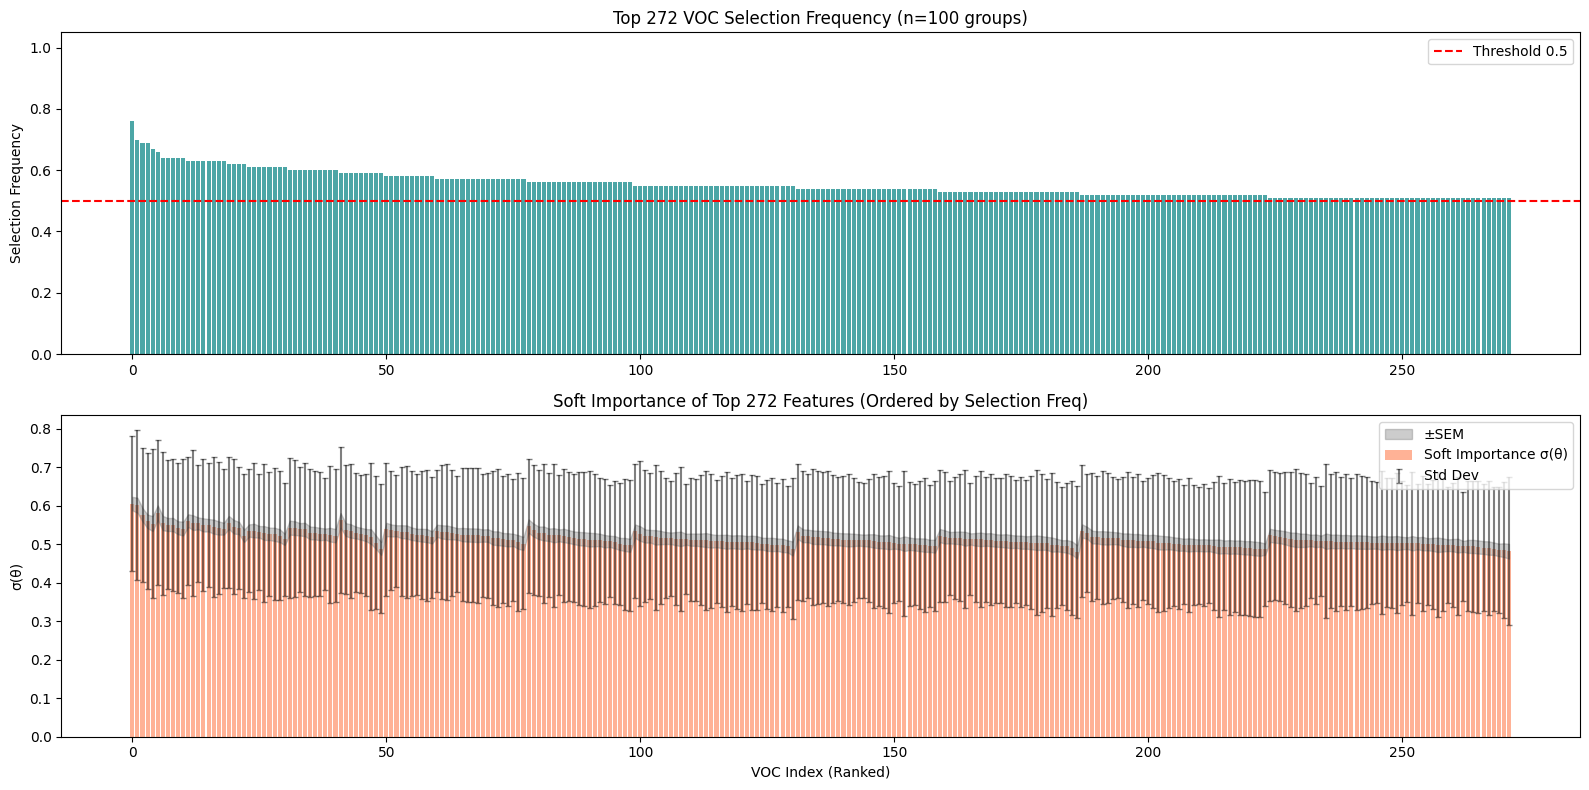

[保存⑩] 特征重要性图 → ./result/unknown_val_seed_selection/feature_importance.png


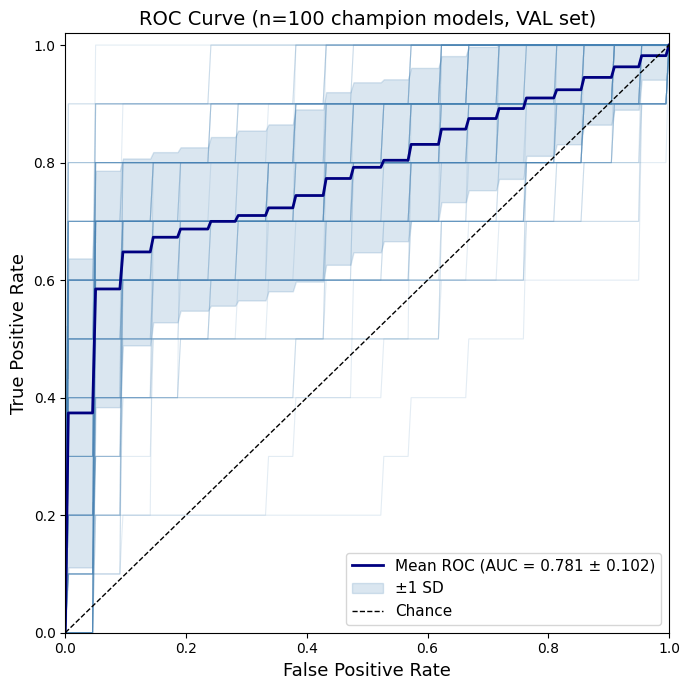

[保存⑪] 验证集ROC曲线 → ./result/unknown_val_seed_selection/val_roc_curve.png

Final Report: averaged over 100 champion models (VAL set)
----------------------------------------------------------------------
Metric            Mean                95% CI
Sensitivity      0.652        [0.623, 0.681]
Specificity      0.960        [0.951, 0.969]
PPV              0.901        [0.881, 0.922]
NPV              0.856        [0.846, 0.866]
Accuracy         0.861        [0.851, 0.870]
F1               0.743        [0.721, 0.765]
AUC              0.781        [0.760, 0.801]
----------------------------------------------------------------------
acc: 86.06%±0.94%.
precision: 90.14%±2.00%.
recall: 65.20%±2.86%.
fpr: 4.00%±0.86%.
f1: 74.30%±2.15%.

注意：以上是验证集结果，用于筛选模型和随机种子，不是最终测试集结果。


In [4]:
formal_result = experiment(
    './data/voc_dataset_1+2_vs_3_with_unknown.mat',
    './result/unknown_val_seed_selection/all_masks.pt',
    num_cluster=3,
    experiment_repeats=100,
    repeats=20,
    epochs=300,
    sparsity_lambda=1e-2,
    temp_start=1.0,
    temp_end=0.3,
    seed=42,
    panel_threshold=0.5
)